In [14]:
import seaborn as sns
palette = sns.color_palette("pastel", 6)

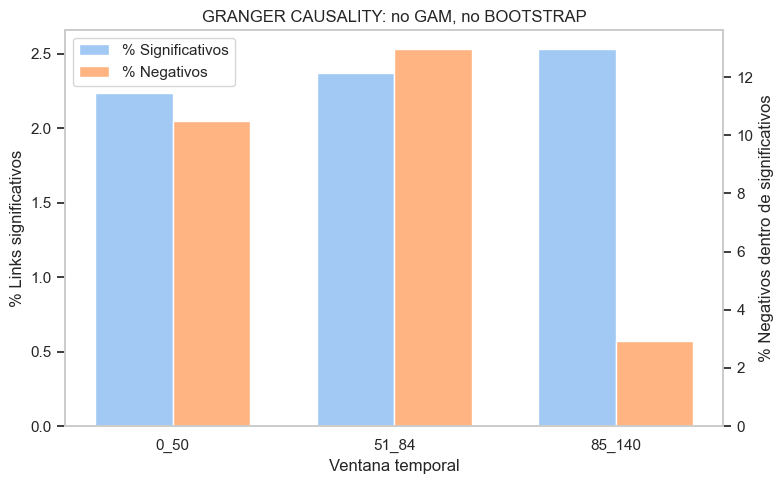

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Crear DataFrame
# -------------------------
data = {
    "ventana": ["0_50", "51_84", "85_140"],
    "pares_analizados": [5550, 4556, 4032],
    "links_significativos": [124, 108, 102],
    "negativos": [13, 14, 3],
}

df = pd.DataFrame(data)

# -------------------------
# Calcular porcentajes
# -------------------------
df["pct_significativos"] = (
    df["links_significativos"] / df["pares_analizados"] * 100
)

df["pct_negativos_dentro_sig"] = (
    df["negativos"] / df["links_significativos"] * 100
)

# -------------------------
# Estética
# -------------------------
sns.set(style="whitegrid")
palette = sns.color_palette("pastel", 2)

# -------------------------
# Gráfico
# -------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(df))
width = 0.35

# Barras eje izquierdo
bars1 = ax1.bar(
    x - width/2,
    df["pct_significativos"],
    width,
    color=palette[0]
)

ax1.set_ylabel("% Links significativos")
ax1.set_xlabel("Ventana temporal")
ax1.set_xticks(x)
ax1.set_xticklabels(df["ventana"])

# Barras eje derecho
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    df["pct_negativos_dentro_sig"],
    width,
    color=palette[1]
)

ax2.set_ylabel("% Negativos dentro de significativos")

# -------------------------
# Leyenda limpia (solo una barra de cada tipo)
# -------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=palette[0], label="% Significativos"),
    Patch(facecolor=palette[1], label="% Negativos")
]

ax1.legend(handles=legend_elements, loc="upper left")

ax1.grid(False)
ax2.grid(False)

plt.title("GRANGER CAUSALITY: no GAM, no BOOTSTRAP")
plt.tight_layout()
plt.show()

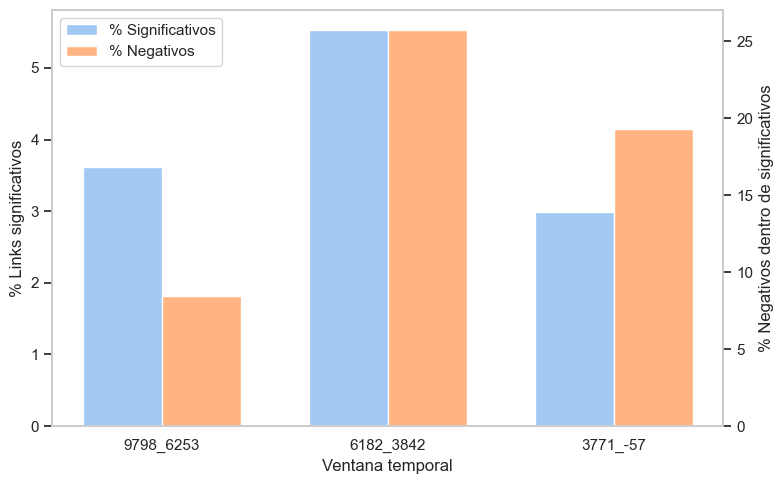

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -------------------------
# Crear DataFrame
# -------------------------
data = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "pares_analizados": [5550, 5550, 5550],
    "links_significativos": [201, 307, 166],
    "negativos": [17, 79, 32],
}

df = pd.DataFrame(data)

# -------------------------
# Calcular porcentajes
# -------------------------
df["pct_significativos"] = (
    df["links_significativos"] / df["pares_analizados"] * 100
)

df["pct_negativos_dentro_sig"] = (
    df["negativos"] / df["links_significativos"] * 100
)

# -------------------------
# Estética
# -------------------------
sns.set(style="whitegrid")
palette = sns.color_palette("pastel", 2)

fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(df))
width = 0.35

# Eje izquierdo
ax1.bar(
    x - width/2,
    df["pct_significativos"],
    width,
    color=palette[0]
)

ax1.set_ylabel("% Links significativos")
ax1.set_xlabel("Ventana temporal")
ax1.set_xticks(x)
ax1.set_xticklabels(df["ventana"])

# Eje derecho
ax2 = ax1.twinx()

ax2.bar(
    x + width/2,
    df["pct_negativos_dentro_sig"],
    width,
    color=palette[1]
)

ax2.set_ylabel("% Negativos dentro de significativos")

# Leyenda limpia
legend_elements = [
    Patch(facecolor=palette[0], label="% Significativos"),
    Patch(facecolor=palette[1], label="% Negativos")
]

ax1.legend(handles=legend_elements, loc="upper left")

ax1.grid(False)
ax2.grid(False)
#plt.title("Links significativos y proporción de negativos por ventana")
plt.tight_layout()
plt.show()

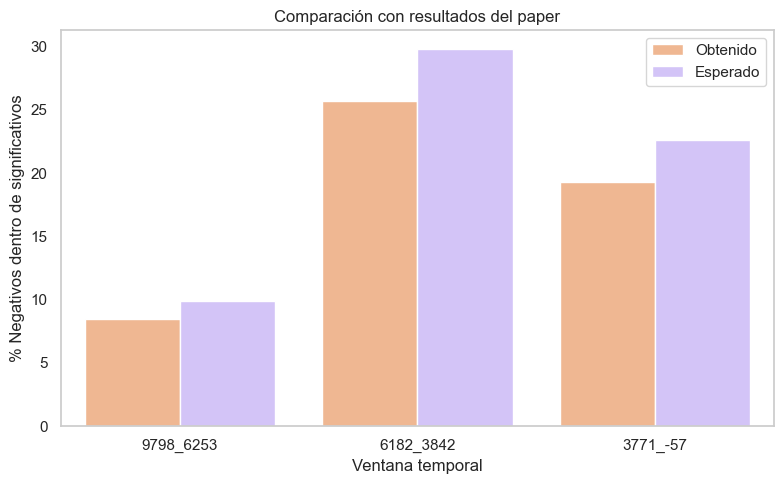

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Datos comparación paper
# -------------------------
comp_data = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [8.5, 25.7, 19.3],
    "Esperado": [9.9, 29.8, 22.6],
}

comp_df = pd.DataFrame(comp_data)

comp_df_melt = comp_df.melt(
    id_vars="ventana",
    var_name="Tipo",
    value_name="Porcentaje"
)

# -------------------------
# Paleta personalizada
# -------------------------
base_palette = sns.color_palette("pastel", 6)

custom_palette = {
    "Obtenido": base_palette[1],
    "Esperado": base_palette[4],
}

# -------------------------
# Gráfico
# -------------------------
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comp_df_melt,
    x="ventana",
    y="Porcentaje",
    hue="Tipo",
    palette=custom_palette
)

plt.grid(False)
plt.ylabel("% Negativos dentro de significativos")
plt.xlabel("Ventana temporal")
plt.title("Comparación con resultados del paper")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [1]:
87/184


0.47282608695652173

In [ ]:
159/369

0.43089430894308944

: 

ValueError: The palette dictionary is missing keys: {'Significativos'}

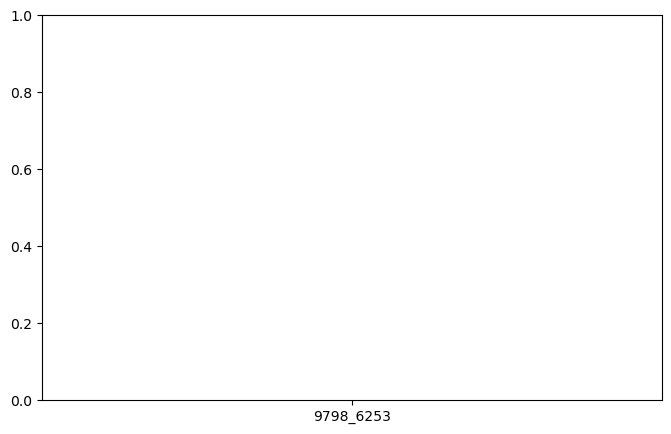

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Datos comparación paper
# -------------------------
data_sin_cond = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [37.9, 50, 47.2],
    "Esperado": [25, 40, 35],
    #"Significativos": [240, 178, 184],
}

data_delta = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [43.95, 52.7, 51.56],
    "Esperado": [25, 40, 35],
    "Significativos": [496, 269, 320],
}

# con 300 bootstraps y con la delta boostrapeada
data_delta = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [43, 52.8, 50],
    "Esperado": [25, 40, 35],
    "Significativos": [369, 269, 247],
}

comp_df = pd.DataFrame(data_delta)

comp_df_melt = comp_df.melt(
    id_vars="ventana",
    var_name="Tipo",
    value_name="Porcentaje"
)

# -------------------------
# Paleta personalizada
# -------------------------
base_palette = sns.color_palette("pastel", 6)

custom_palette = {
    "Obtenido": base_palette[1],
    "Esperado": base_palette[4],
}

# -------------------------
# Gráfico
# -------------------------
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comp_df_melt,
    x="ventana",
    y="Porcentaje",
    hue="Tipo",
    palette=custom_palette
)

plt.grid(False)
plt.ylabel("% Negativos dentro de significativos")
plt.xlabel("Ventana temporal")
plt.title("Comparación con resultados del paper")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [18]:

data_delta_multiplicadores = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [43.3, 54.4, 52.0],
    "Esperado": [25, 40, 35],
    "Significativos": [337, 204, 244],
}

data_delta = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [41.2, 55.3, 50],
    "Esperado": [25, 40, 35],
    "Significativos": [335, 242, 218],
}

data_sin_condicionales = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [36.9, 49.3, 48.9],
    "Esperado": [25, 40, 35],
    "Significativos": [301, 209, 219],
}

In [3]:
130/279

0.4659498207885305

In [2]:
96/200

0.48

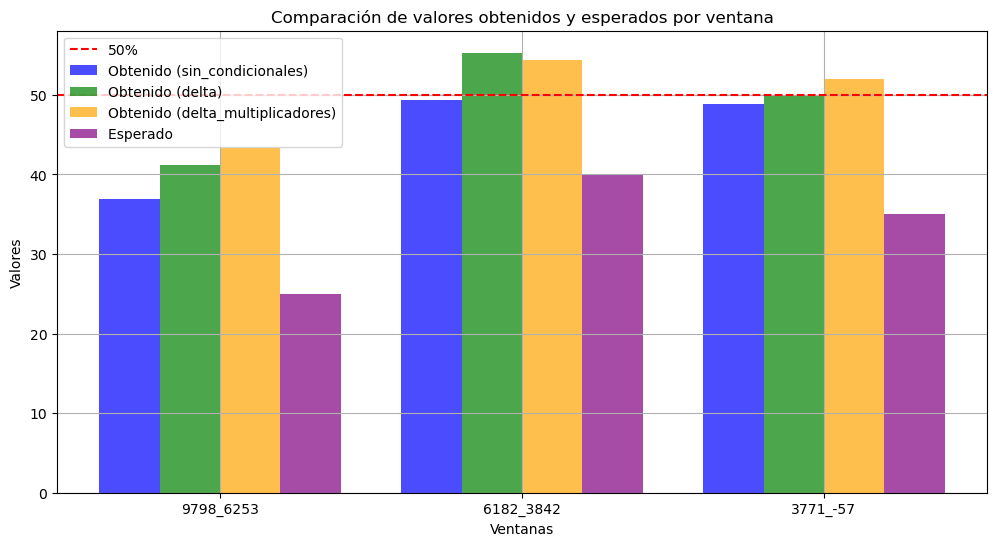

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Configuración del gráfico
x = np.arange(len(data["ventana"]))  # posición de las ventanas
width = 0.2  # ancho de las barras

fig, ax = plt.subplots(figsize=(12, 6))

# Crear las barras para cada conjunto de datos
bars1 = ax.bar(x - 1.5*width, data_sin_condicionales["Obtenido"], width, label='Obtenido (sin_condicionales)', color='blue', alpha=0.7)
bars2 = ax.bar(x - 0.5*width, data_delta["Obtenido"], width, label='Obtenido (delta)', color='green', alpha=0.7)
bars3 = ax.bar(x + 0.5*width, data_delta_multiplicadores["Obtenido"], width, label='Obtenido (delta_multiplicadores)', color='orange', alpha=0.7)
bars4 = ax.bar(x + 1.5*width, data_sin_condicionales["Esperado"], width, label='Esperado ', color='purple', alpha=0.7)
ax.grid()

ax.axhline(y=50, color='red', linestyle='dashed', label='50%')
# Personalizar el gráfico
ax.set_xlabel('Ventanas')
ax.set_ylabel('Valores')
ax.set_title('Comparación de valores obtenidos y esperados por ventana')
ax.set_xticks(x)
ax.set_xticklabels(data_sin_condicionales["ventana"])
ax.legend()

con delta y 500 boostrap
n_min=10


Especies válidas: 66
Generando bootstrap...
Bootstrap generados.

============================================================
VENTANA: 9798_6253
============================================================
Significativos: 295
Cola baja: 114
Cola alta: 181


Especies válidas: 66
Generando bootstrap...
Bootstrap generados.

============================================================
VENTANA: 6182_3842
============================================================
Significativos: 280
Cola baja: 148
Cola alta: 132


boots 1000
ab_min 0.5
delta y multipliers

============================================================
VENTANA: 9798_6253
============================================================
65 especies validas
Significativos: 370 (8.89%)
Cola baja: 122 (33.0%)
Cola alta: 248 (67.0%)


============================================================
VENTANA: 6182_3842
============================================================
62 especies validas
Significativos: 212 (5.61%)
Cola baja: 77 (36.3%)
Cola alta: 135 (63.7%)


============================================================
VENTANA: 3771_-57
============================================================
70 especies validas
Significativos: 273 (5.63%)
Cola baja: 101 (37.0%)
Cola alta: 172 (63.0%)




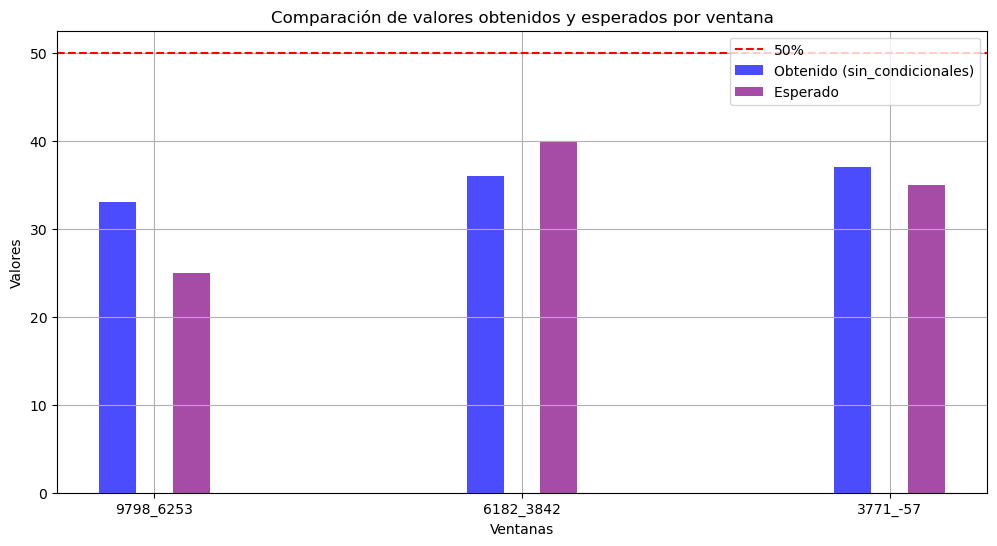

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data_delta_multiplicadores = {
    "ventana": ["9798_6253", "6182_3842", "3771_-57"],
    "Obtenido": [33, 36, 37],
    "Esperado": [25, 40, 35],
    "Significativos": [337, 204, 244],
}


x = np.arange(len(data_delta_multiplicadores["ventana"]))  # posición de las ventanas
x=(x - 0.5)*2
width = 0.2  # ancho de las barras

fig, ax = plt.subplots(figsize=(12, 6))

# Crear las barras para cada conjunto de datos
bars1 = ax.bar(x - 1*width, data_delta_multiplicadores["Obtenido"], width, label='Obtenido (sin_condicionales)', color='blue', alpha=0.7)
bars4 = ax.bar(x + 1*width, data_delta_multiplicadores["Esperado"], width, label='Esperado ', color='purple', alpha=0.7)
ax.grid()

ax.axhline(y=50, color='red', linestyle='dashed', label='50%')
# Personalizar el gráfico
ax.set_xlabel('Ventanas')
ax.set_ylabel('Valores')
ax.set_title('Comparación de valores obtenidos y esperados por ventana')
ax.set_xticks(x)
ax.set_xticklabels(data_delta_multiplicadores["ventana"])
ax.legend()